In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [2]:
df = df.drop(
    ["CustomerID", "Tenure", "Usage Frequency", "Subscription Type", "Contract Length"], axis=1
)
df.head()

,Age,Gender,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
0,30.0,Female,5.0,18.0,932.0,17.0,1.0
1,65.0,Female,10.0,8.0,557.0,6.0,1.0
2,55.0,Female,6.0,18.0,185.0,3.0,1.0
3,58.0,Male,7.0,7.0,396.0,29.0,1.0
4,23.0,Male,5.0,8.0,617.0,20.0,1.0


In [3]:
import numpy as np

gender_ohe = pd.get_dummies(df["Gender"], dtype=np.int8)
df = df.drop(["Gender"], axis=1)
df = df.join(gender_ohe)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male
0,30.0,5.0,18.0,932.0,17.0,1.0,1,0
1,65.0,10.0,8.0,557.0,6.0,1.0,1,0
2,55.0,6.0,18.0,185.0,3.0,1.0,1,0
3,58.0,7.0,7.0,396.0,29.0,1.0,0,1
4,23.0,5.0,8.0,617.0,20.0,1.0,0,1


In [4]:
def classify_age_group(age):
    if 18 <= age <= 24:
        return "Young Adult"
    elif 24 < age <= 39:
        return "Adult"
    elif 39 < age <= 59:
        return "Mid-Career"
    elif age >= 60:
        return "Senior"


df["Age Group"] = df["Age"].apply(classify_age_group)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Age Group
0,30.0,5.0,18.0,932.0,17.0,1.0,1,0,Adult
1,65.0,10.0,8.0,557.0,6.0,1.0,1,0,Senior
2,55.0,6.0,18.0,185.0,3.0,1.0,1,0,Mid-Career
3,58.0,7.0,7.0,396.0,29.0,1.0,0,1,Mid-Career
4,23.0,5.0,8.0,617.0,20.0,1.0,0,1,Young Adult


In [5]:
df["Age Group"].value_counts()

Age Group
Mid-Career     186203
Adult          157952
Young Adult     64036
Senior          32641
Name: count, dtype: int64

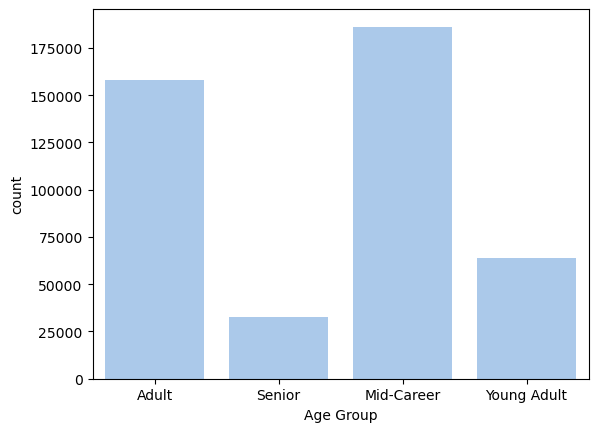

In [6]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_palette("pastel")

sns.countplot(data=df, x="Age Group")
plt.show()

In [7]:
def classify_interaction_frequency(last_interaction):
    if 0 < last_interaction <= 7:
        return "Highly Active"
    elif 7 < last_interaction <= 15:
        return "Active"
    elif last_interaction > 15:
        return "Dormant"


df["Interaction Frequency"] = df["Last Interaction"].apply(
    classify_interaction_frequency
)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Age Group,Interaction Frequency
0,30.0,5.0,18.0,932.0,17.0,1.0,1,0,Adult,Dormant
1,65.0,10.0,8.0,557.0,6.0,1.0,1,0,Senior,Highly Active
2,55.0,6.0,18.0,185.0,3.0,1.0,1,0,Mid-Career,Highly Active
3,58.0,7.0,7.0,396.0,29.0,1.0,0,1,Mid-Career,Dormant
4,23.0,5.0,8.0,617.0,20.0,1.0,0,1,Young Adult,Dormant


In [8]:
df['Age Group'].value_counts(dropna=False)

Age Group
Mid-Career     186203
Adult          157952
Young Adult     64036
Senior          32641
Name: count, dtype: int64

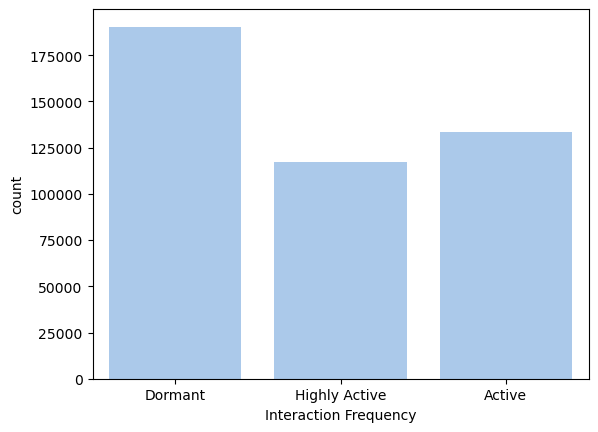

In [9]:
sns.countplot(data=df, x="Interaction Frequency")
plt.show()

In [10]:
age_mapping = {"Young Adult": 0, "Adult": 1, "Mid-Career": 2, "Senior": 3}

interaction_mapping = {"Highly Active": 0, "Active": 1, "Dormant": 2}

df["Age Group"] = df["Age Group"].apply(lambda age: age_mapping[age])
df["Interaction Frequency"] = df["Interaction Frequency"].apply(
    lambda age: interaction_mapping[age]
)
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Female,Male,Age Group,Interaction Frequency
0,30.0,5.0,18.0,932.0,17.0,1.0,1,0,1,2
1,65.0,10.0,8.0,557.0,6.0,1.0,1,0,3,0
2,55.0,6.0,18.0,185.0,3.0,1.0,1,0,2,0
3,58.0,7.0,7.0,396.0,29.0,1.0,0,1,2,2
4,23.0,5.0,8.0,617.0,20.0,1.0,0,1,0,2


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_no_label = df.drop(["Churn", "Female"], axis=1)
df_no_label = pd.DataFrame(
    scaler.fit_transform(df_no_label), columns=df_no_label.columns
)
df_no_label.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age Group,Interaction Frequency
0,-0.753326,0.454549,0.609620,1.247427,0.293052,-1.145909,-0.514510,1.018461
1,2.059646,2.083100,-0.601319,-0.309865,-0.986584,-1.145909,1.905480,-1.425340
2,1.255940,0.780259,0.609620,-1.854698,-1.335575,-1.145909,0.695485,-1.425340
3,1.497051,1.105969,-0.722413,-0.978462,1.689018,0.872670,0.695485,1.018461
4,-1.315921,0.454549,-0.601319,-0.060698,0.642043,0.872670,-1.724505,1.018461


In [12]:
df = df_no_label.join(df["Churn"])
df.head()

,Age,Support Calls,Payment Delay,Total Spend,Last Interaction,Male,Age Group,Interaction Frequency,Churn
0,-0.753326,0.454549,0.609620,1.247427,0.293052,-1.145909,-0.514510,1.018461,1.0
1,2.059646,2.083100,-0.601319,-0.309865,-0.986584,-1.145909,1.905480,-1.425340,1.0
2,1.255940,0.780259,0.609620,-1.854698,-1.335575,-1.145909,0.695485,-1.425340,1.0
3,1.497051,1.105969,-0.722413,-0.978462,1.689018,0.872670,0.695485,1.018461,1.0
4,-1.315921,0.454549,-0.601319,-0.060698,0.642043,0.872670,-1.724505,1.018461,1.0


In [13]:
import os

os.makedirs("../data/preprocessed", exist_ok=True)
df.to_parquet("../data/preprocessed/train.parquet", index=False)